<a href="https://colab.research.google.com/github/carlottaforza03/Progetto-IntroDSePC-Gruppo-6/blob/Branch_Gaia/Progetto_IntroDSePC_gruppo_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Progetto del corso - IntroDSePC - a.a. 2025/2026

#Membri del gruppo 6


Il gruppo 6 è composto da:


*   **Gaia** **Bellomo**: matricola 1226500 gaia.bellomo3@studio.unibo.it
*   **Carlotta** **Forza**: matricola 1230704 carlotta.forza@studio.unibo.it
*   **Federica** **La** **Braca**: matricola 1216267 federica.labraca@studio.unibo.it





#Materiale del progetto

*   *Online_Shoppers.csv*: il dataset utilizzato per le fasi 2 e 3 del progetto
*   *IntroDSePC_25-26_11*: dispensa con le specifiche del progetto
*   *https://github.com/carlottaforza03/Progetto-IntroDSePC-Gruppo-6*: il repository GitHub
*  *https://www.overleaf.com/read/hqdjbthxcfxj#0b54f9*: il link al Report su Overleaf






#Preparazione dell'ambiente

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             ConfusionMatrixDisplay, classification_report)

Importazione del repository da GitHub

In [ ]:
!git clone https://github.com/carlottaforza03/Progetto-IntroDSePC-Gruppo-6

fatal: destination path 'Progetto-IntroDSePC-Gruppo-6' already exists and is not an empty directory.


#Fase 1: Analisi e comprensione del Dataset

Inserire il Dataset

In [ ]:
shopping = pd.read_csv("sample_data/Online_Shoppers.csv", sep=",")
print(shopping)

       Administrative  Administrative_Duration  Informational  \
0                   0                      0.0              0   
1                   0                      0.0              0   
2                   0                      0.0              0   
3                   0                      0.0              0   
4                   0                      0.0              0   
...               ...                      ...            ...   
12325               3                    145.0              0   
12326               0                      0.0              0   
12327               0                      0.0              0   
12328               4                     75.0              0   
12329               0                      0.0              0   

       Informational_Duration  ProductRelated  ProductRelated_Duration  \
0                         0.0               1                 0.000000   
1                         0.0               2                64.000000 

In [ ]:
shopping.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

In [ ]:
valori_mancanti = shopping.isnull().sum()
print("Conteggio dei valori mancanti per ogni colonna:\n", valori_mancanti)

Conteggio dei valori mancanti per ogni colonna:
 Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64


# Fase 2: Descrizione e comprensione del Dataset

Il progetto si focalizza sullo studio analitico del comportamento degli utenti durante le sessioni di navigazione su una piattaforma di e-commerce, sfruttando le informazioni raccolte nel dataset degli acquirenti online.

Lo scopo fondamentale dell'analisi consiste nel prevedere l'intenzione d'acquisto dei visitatori, identificando se una determinata sessione si concluderà o meno con una transazione andata a buon fine.

Attraverso l'esplorazione di metriche web come il tasso di rimbalzo, il valore delle pagine e la durata della navigazione, il progetto mira a fornire un'interpretazione critica delle dinamiche digitali per aiutare a comprendere quali fattori spingano concretamente un utente alla conversione.

##Domande/ipotesi

###Domanda 1
Quale sorgente di traffico garantisce il tasso di conversione in acquisti più elevato e risulta quindi essere il canale di acquisizione più redditizio per la piattaforma web?


In [ ]:
conversione_traffico = shopping.groupby('TrafficType')['Revenue'].mean() * 100
print("Tasso di conversione per ogni sorgente di traffico:\n", conversione_traffico)

Tasso di conversione per ogni sorgente di traffico:
 TrafficType
1     10.689514
2     21.645796
3      8.771930
4     15.434986
5     21.538462
6     11.936937
7     30.000000
8     27.696793
9      9.523810
10    20.000000
11    19.028340
12     0.000000
13     5.826558
14    15.384615
15     0.000000
16    33.333333
17     0.000000
18     0.000000
19     5.882353
20    25.252525
Name: Revenue, dtype: float64


Valutando l'efficacia dei canali di acquisizione, emerge chiaramente che la sorgente di traffico categorizzata con il numero 16 risulta essere la più redditizia, garantendo un tasso di conversione del 33.33%.

### Domanda 2
Esiste un forte sbilanciamento tra gli utenti che completano l'acquisto e quelli che abbandonano il sito?

In [ ]:
sbilanciamento_target = shopping['Revenue'].value_counts(normalize=True) * 100
print("Percentuale di acquisti e non acquisti:\n", sbilanciamento_target)

Percentuale di acquisti e non acquisti:
 Revenue
False    84.525547
True     15.474453
Name: proportion, dtype: float64


Dall'analisi della variabile target emerge un forte sbilanciamento delle classi: la percentuale di sessioni che terminano con un acquisto è del 15.47%, mentre il restante 84.53% si conclude con l'abbandono del sito.

###Domanda 3
Le abitudini di acquisto degli utenti cambiano in modo significativo in base al giorno della settimana, registrando un tasso di conversione proporzionalmente maggiore durante le giornate del fine settimana rispetto alla classica navigazione effettuata nei giorni lavorativi?


In [ ]:
affluenza_weekend = shopping.groupby('Weekend')['Revenue'].mean() * 100
print(affluenza_weekend)

Weekend
False    14.891144
True     17.398884
Name: Revenue, dtype: float64


Il valore che compare accanto all'etichetta False indica l'esatta percentuale di acquisti andati a buon fine dal lunedì al venerdì, mentre il numero in corrispondenza dell'etichetta True quantifica la percentuale di conversioni per il sabato e la domenica

###Domanda 4

Ci sono valori anomali nella durata media delle sessioni? (utenti che risultano connessi per una quantità di ore irrealistica)

In [ ]:
colonne_durata = ['Administrative_Duration', 'Informational_Duration', 'ProductRelated_Duration']
analisi_durata = shopping[colonne_durata].describe()
print(analisi_durata)

       Administrative_Duration  Informational_Duration  \
count             12330.000000            12330.000000   
mean                 80.818611               34.472398   
std                 176.779107              140.749294   
min                   0.000000                0.000000   
25%                   0.000000                0.000000   
50%                   7.500000                0.000000   
75%                  93.256250                0.000000   
max                3398.750000             2549.375000   

       ProductRelated_Duration  
count             12330.000000  
mean               1194.746220  
std                1913.669288  
min                   0.000000  
25%                 184.137500  
50%                 598.936905  
75%                1464.157214  
max               63973.522230  


La durata media di navigazione sulle pagine dei prodotti si attesta a 1194.75 secondi, ma il valore massimo registrato tocca un picco estremo di 63973.52 secondi, suggerendo la chiara presenza di valori anomali da trattare.

###Domanda 5
In quali mesi dell'anno si concentra il maggior numero di accessi alla piattaforma di e-commerce?

In [ ]:
traffico_mensile = shopping['Month'].value_counts()
print(traffico_mensile)

Month
May     3364
Nov     2998
Mar     1907
Dec     1727
Oct      549
Sep      448
Aug      433
Jul      432
June     288
Feb      184
Name: count, dtype: int64


Valutando la distribuzione temporale, il mese di May (maggio) risulta essere il periodo con la maggiore concentrazione di accessi, registrando un volume totale di 3364 sessioni.

###Domanda 6
Qual è il valore medio per il tasso di rimbalzo globale del sito? (calcolarlo e capire se la piattaforma presenta problemi tecnici o di usabilità).

In [ ]:
media_rimbalzo = shopping['BounceRates'].mean()
print("Rimbalzo medio totale:", media_rimbalzo)

Rimbalzo medio totale: 0.02219138047072182


Il tasso di rimbalzo medio globale pari al 2,22% suggerisce l'assenza di evidenti problematiche tecniche o strutturali e può indicare un'elevata usabilità del sito, confermando che gli utenti in entrata trovano un'interfaccia intuitiva ed in target con le loro intenzioni di ricerca.

###Domanda 7
Esistono colonne che esprimono concetti sovrapponibili o quasi identici, rischiando di inserire informazioni duplicate?

In [ ]:
correlazione_metriche = shopping[['BounceRates', 'ExitRates']].corr()
print(correlazione_metriche)

             BounceRates  ExitRates
BounceRates     1.000000   0.913004
ExitRates       0.913004   1.000000


L'indice di correlazione tra il tasso di rimbalzo e il tasso di uscita risulta essere di 0.91, indicando una fortissima somiglianza strutturale che rischia di inserire informazioni duplicate nel modello.

###Domanda 8
Quanto incidono numericamente le giornate speciali, verificando quante sessioni di navigazione avvengono in prossimità di eventi come San Valentino o Natale?

In [ ]:
volume_giornate_speciali = shopping[shopping['SpecialDay'] > 0]['SpecialDay'].count()
print("Totale sessioni vicine a festività:", volume_giornate_speciali)

Totale sessioni vicine a festività: 1251


## Statistiche descrittive

### Statistica 1
Frequenza degli acquisti nel dataset (variabile Revenue)

In [ ]:
print(shopping['Revenue'].value_counts())
print(shopping['Revenue'].value_counts(normalize=True).mul(100).round(2))


Revenue
False    10422
True      1908
Name: count, dtype: int64
Revenue
False    84.53
True     15.47
Name: proportion, dtype: float64


Il dataset presenta un evidente sbilanciamento tra le classi, in quanto solo il 15,47% delle sessioni si conclude con un acquisto, mentre l'84,53% non genera conversioni.

###Statistica 2
Distribuzione delle pagine prodotto visitate

In [ ]:
print(shopping['ProductRelated'].describe())


count    12330.000000
mean        31.731468
std         44.475503
min          0.000000
25%          7.000000
50%         18.000000
75%         38.000000
max        705.000000
Name: ProductRelated, dtype: float64


Gli utenti visitano in media 31,7 pagine prodotto per sessione, ma la mediana è pari a 18. La presenza di sessioni con valori molto elevati (fino a 705 pagine) suggerisce una distribuzione asimmetrica e la possibile presenza di outlier.

###Statistica 3
Incidenza delle sessioni prive di valore economico stimato (PageValues = 0)

In [ ]:
zero_pv = (shopping['PageValues'] == 0).sum()
print(f"Sessioni con PageValues = 0: {zero_pv} ({zero_pv/len(shopping)*100:.1f}%)")
print(shopping.groupby(shopping['PageValues'] == 0)['Revenue'].mean().rename({True: 'PageValues = 0', False: 'PageValues > 0'}))


Sessioni con PageValues = 0: 9600 (77.9%)
PageValues
PageValues > 0    0.563370
PageValues = 0    0.038542
Name: Revenue, dtype: float64


Il 77,9% delle sessioni presenta un valore di PageValues pari a zero. Inoltre, il tasso di acquisto passa dal 3,85% per le sessioni con PageValues = 0 al 56,34% per quelle con PageValues > 0, indicando una forte relazione tra questa variabile e la conversione.

###Statistica 4
Relazione tra tasso di rimbalzo e tasso di uscita

In [ ]:
shopping['Revenue_num'] = shopping['Revenue'].astype(int)
print(shopping[['BounceRates', 'ExitRates', 'Revenue_num']].corr())


             BounceRates  ExitRates  Revenue_num
BounceRates     1.000000   0.913004    -0.150673
ExitRates       0.913004   1.000000    -0.207071
Revenue_num    -0.150673  -0.207071     1.000000


Le variabili BounceRates ed ExitRates mostrano una correlazione molto elevata (0,913), indicando che descrivono comportamenti di navigazione fortemente simili.
Entrambe mostrano una correlazione negativa con Revenue, indicando che un maggiore tasso di abbandono del sito è associato a una minore probabilità di acquisto.

###Statistica 5
Quali variabili sono più associate all'acquisto?


In [ ]:
shopping['Revenue_num'] = shopping['Revenue'].astype(int)
print(shopping.select_dtypes(include='number').corr()['Revenue_num'].sort_values(ascending=False))

Revenue_num                1.000000
PageValues                 0.492569
ProductRelated             0.158538
ProductRelated_Duration    0.152373
Administrative             0.138917
Informational              0.095200
Administrative_Duration    0.093587
Informational_Duration     0.070345
Browser                    0.023984
TrafficType               -0.005113
Region                    -0.011595
OperatingSystems          -0.014668
SpecialDay                -0.082305
BounceRates               -0.150673
ExitRates                 -0.207071
Name: Revenue_num, dtype: float64


 PageValues è di gran lunga la variabile più correlata al target (0.49), seguita da ProductRelated e ProductRelated_Duration (~0.15). Variabili come TrafficType, Region e OperatingSystems hanno correlazione quasi nulla, il che suggerisce che da sole hanno poco potere predittivo. SpecialDay è l'unica variabile "di contesto" con correlazione negativa rilevante (-0.08), confermando il risultato controintuitivo già osservato nelle domande.

##Riflessioni critiche sui dati

###Riflessione 1
Comportamento d'acquisto per tipologia di utente


In [ ]:
contingenza_visitatori = pd.crosstab(shopping['VisitorType'], shopping['Revenue'], normalize='index') * 100
print("Percentuale di conversione (Revenue) in base al tipo di visitatore:")
print(contingenza_visitatori)


Percentuale di conversione (Revenue) in base al tipo di visitatore:
Revenue                False      True 
VisitorType                            
New_Visitor        75.088548  24.911452
Other              81.176471  18.823529
Returning_Visitor  86.067671  13.932329


Incrociando il tipo di visitatore (⁠VisitorType⁠) con il successo della sessione (⁠Revenue⁠), notiamo un dato interessante: un nuovo visitatore ha una probabilità di convertire (24,91%) quasi doppia, rispetto ad un visitatore che ritorna sul sito (13,93%).Questo dimostra che, mentre gli utenti fidelizzati esplorano il sito in modo informativo (generando molte sessioni ma senza acquistare sempre), i nuovi utenti approdano sulla piattaforma con un intento d'acquisto più immediato e mirato. In ottica di modellazione predittiva, la feature ⁠VisitorType⁠ agisce quindi come un forte discriminatore probabilistico.

###Riflessione 2
Impatto degli outlier

In [ ]:

print("TEMPO MASSIMO SPESO SUI PRODOTTI")
print(shopping.groupby('Revenue')['ProductRelated_Duration'].max())


TEMPO MASSIMO SPESO SUI PRODOTTI
Revenue
False    63973.52223
True     27009.85943
Name: ProductRelated_Duration, dtype: float64


Dall'analisi dei massimali si evidenzia una forte presenza di outliers nel dataset. Per chi non acquista il valore massimo è di 63973.52 secondi (circa 17 ore e 46 minuti); mentre per chi acquista il valore massimo è di 27009.86 (circa 7 ore e 30 minuti)
Il dato non segue quindi una distribuzione simmetrica ma è caratterizzata da una forte asimmetria positiva. Il tempo speso sul sito non ha una relazione lineare con l'acquisto ma diventa più un sinonimo di inattività .

###Riflessione 3
Comportamento d'acquisto per mese


In [ ]:
ordine_mesi = ['Feb', 'Mar', 'May', 'June', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
percentuale_mesi = shopping.groupby('Month')['Revenue'].mean() * 100
print("TASSO DI CONVERSIONE % PER OGNI MESE")
print(percentuale_mesi.reindex(ordine_mesi))


TASSO DI CONVERSIONE % PER OGNI MESE
Month
Feb      1.630435
Mar     10.068170
May     10.850178
June    10.069444
Jul     15.277778
Aug     17.551963
Sep     19.196429
Oct     20.947177
Nov     25.350233
Dec     12.507238
Name: Revenue, dtype: float64


Si evidenzia una forte stagionalità nella relazione tra acquisto e mese. Il mese di novembre evidenzia un tasso di conversione del 25,35%, nettamente superiore rispetto alla media degli altri mesi dell'anno. Possiamo trovare la spiegazione nel Black Friday e nell'inizio dello shopping in vista delle festività natalizie.

###Riflessione 4
Comportamento d'acquisto per regione


In [ ]:

print("VOLUME DI TRAFFICO PER REGIONE")
print(shopping['Region'].value_counts())

print("TASSO DI CONVERSIONE % PER REGIONE")
crosstab_region = pd.crosstab(shopping['Region'], shopping['Revenue'], normalize='index') * 100
print(crosstab_region)


VOLUME DI TRAFFICO PER REGIONE
Region
1    4780
3    2403
4    1182
2    1136
6     805
7     761
9     511
8     434
5     318
Name: count, dtype: int64
TASSO DI CONVERSIONE % PER REGIONE
Revenue      False      True 
Region                       
1        83.870293  16.129707
2        83.450704  16.549296
3        85.476488  14.523512
4        85.194585  14.805415
5        83.647799  16.352201
6        86.086957  13.913043
7        84.362681  15.637319
8        87.096774  12.903226
9        83.170254  16.829746


L'analisi mostra che il traffico si concentra fortemente in alcune regioni, ma il tasso di conversione varia di  regione in regione non seguendo un andamento matematico ma possibilmente rispondendo a dinamiche reali. Dai risultati ottenuti nelle statistiche emerge una correlazione con valore lineare vicino allo zero (-0,11) che evidenzia la relazione non lineare tra le feature.

# Fase 3: Analisi esplorativa dei dati e visualizzazione

##Grafici

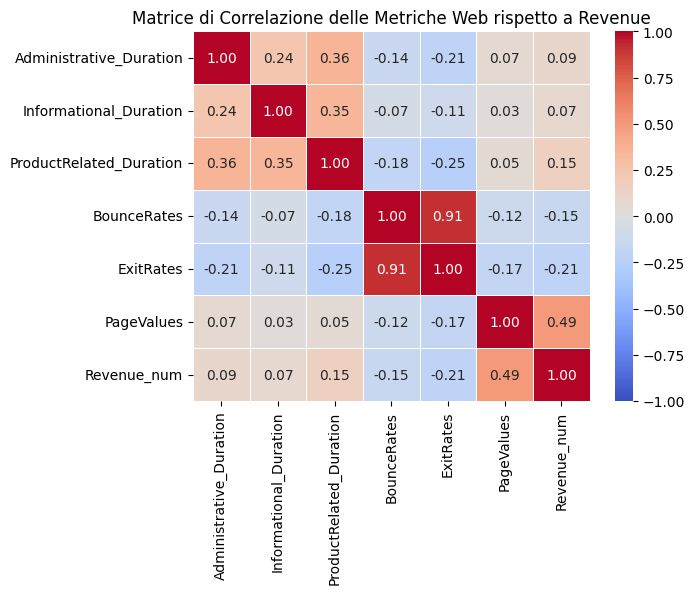

In [ ]:
metriche_chiave = ['Administrative_Duration', 'Informational_Duration', 'ProductRelated_Duration',
                   'BounceRates', 'ExitRates', 'PageValues', 'Revenue_num']

corr_matrix = shopping[metriche_chiave].corr()

sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Matrice di Correlazione delle Metriche Web rispetto a Revenue')
plt.show()

La heatmap evidenzia che la variabile PageValues possiede la più forte correlazione positiva con il target (Revenue_num), confermandosi il predittore principale dell'intento d'acquisto. Al contrario, ExitRates e BounceRates mostrano una correlazione negativa con la conversione e un legame quasi lineare tra loro (0.91). Questa forte collinearità indica una ridondanza informativa tra i tassi di abbandono.

###Grafico 1
Impatto della Tipologia di Visitatore sul Tasso di Conversione

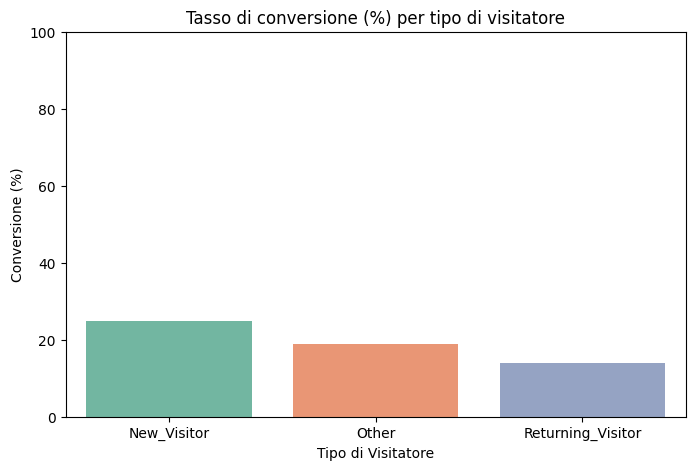

In [ ]:
conv_visitor = shopping.groupby('VisitorType')['Revenue_num'].mean() * 100
conv_visitor = conv_visitor.reset_index()

plt.figure(figsize=(8, 5))
sns.barplot(data=conv_visitor, x='VisitorType', y='Revenue_num', hue='VisitorType', palette='Set2', legend=False)

plt.title('Tasso di conversione (%) per tipo di visitatore')
plt.ylabel('Conversione (%)')
plt.xlabel('Tipo di Visitatore')
plt.ylim(0, 100)
plt.show()

L'analisi evidenzia che i nuovi visitatori (New Visitor) registrano un tasso di conversione vicino al 25%, maggiore rispetto a quelli di ritorno (Returning Visitor), fermi al 14%. Nonostante i clienti abituali generino l'85.5% del traffico totale, il loro comportamento è spesso esplorativo. Al contrario, un nuovo utente approda sul sito con un bisogno specifico e un intento d'acquisto immediato.

###Grafico 2
Correlazione tra Tassi di Rimbalzo ed Uscita nel Processo d'Acquisto

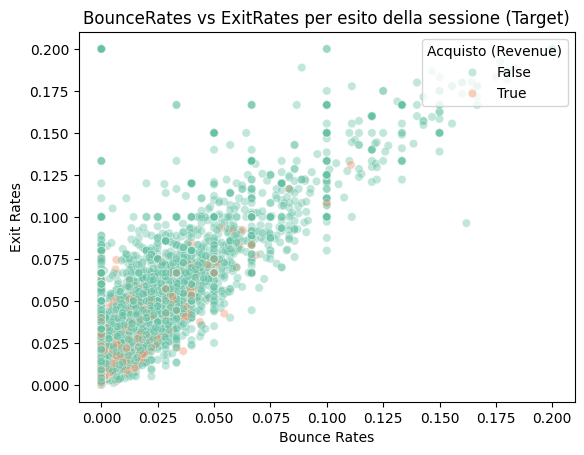

In [ ]:
sns.scatterplot(data=shopping, x='BounceRates', y='ExitRates', hue='Revenue', palette='Set2', alpha=0.4)

plt.title('BounceRates vs ExitRates per esito della sessione (Target)')
plt.xlabel('Bounce Rates')
plt.ylabel('Exit Rates')
plt.legend(title='Acquisto (Revenue)', loc='upper right')
plt.show()

Il grafico mostra una forte linearità positiva tra BounceRates ed ExitRates (correlazione a 0.91), con le conversioni (Revenue=True) concentrate esclusivamente nell'angolo in basso a sinistra, dove entrambi i tassi sono vicini allo zero. Ciò dimostra che all'aumentare dei tassi di rimbalzo e di uscita la probabilità di acquisto si annulla.

###Grafico 3
Andamento Stagionale della Conversione e Finestre Temporali di Vendita

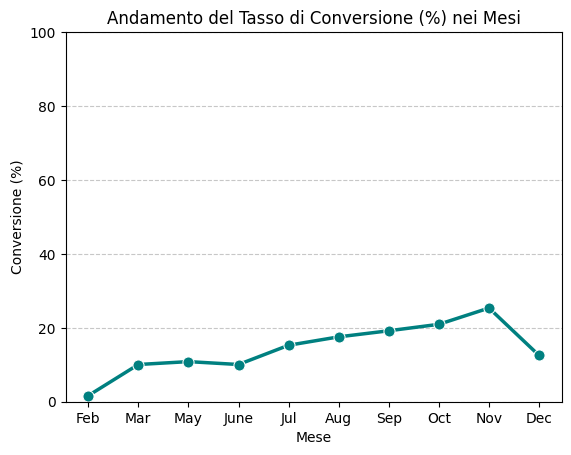

In [ ]:
ordine_mesi = ['Feb', 'Mar', 'May', 'June', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
conv_mesi = shopping.groupby('Month')['Revenue_num'].mean() * 100
conv_mesi = conv_mesi.reindex(ordine_mesi).reset_index()

sns.lineplot(data=conv_mesi, x='Month', y='Revenue_num', marker='o', color='teal', linewidth=2.5, markersize=8)

plt.title('Andamento del Tasso di Conversione (%) nei Mesi')
plt.ylabel('Conversione (%)')
plt.xlabel('Mese')
plt.ylim(0, 100)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Il trend mensile mostra forti oscillazioni della conversione: si passa da un minimo storico a febbraio (sotto il 2%) al picco di novembre, che supera il 25%. Questa evidenza dimostra che la stagionalità non è un semplice dato di contesto, ma riflette l'impatto di dinamiche macroeconomiche esterne (come il Black Friday o lo shopping natalizio) capaci di condizionare la propensione all'acquisto a prescindere dal comportamento del singolo utente.

###Grafico 4
Distribuzione del Tempo di Navigazione sulle Pagine Prodotto rispetto al Target

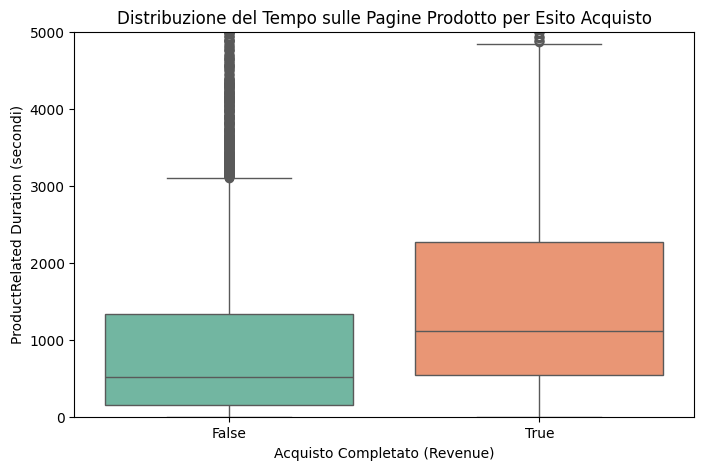

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=shopping,
    x='Revenue',
    y='ProductRelated_Duration',
    hue='Revenue',
    palette='Set2',
    legend=False
)
plt.ylim(0, 5000)
plt.title('Distribuzione del Tempo sulle Pagine Prodotto per Esito Acquisto')
plt.xlabel('Acquisto Completato (Revenue)')
plt.ylabel('ProductRelated Duration (secondi)')
plt.show()

Il boxplot evidenzia una differenza significativa tra le due classi: gli utenti che completano un acquisto (Revenue=1) trascorrono in mediana quasi il doppio del tempo sulle pagine prodotto rispetto a chi abbandona (Revenue=0), con una distribuzione più ampia che si estende fino a 2300 secondi. Questo risultato è controintuitivo: una navigazione più lunga e approfondita non indica indecisione, ma si configura come un segnale predittivo positivo dell'intenzione d'acquisto. Il taglio a 5000 secondi è stato applicato deliberatamente per garantire la leggibilità del grafico, escludendo i valori anomali estremi già discussi nella Fase 2.

##Domande


###Domanda 1
L'effetto combinato tra fine settimana e profilo utente impatta sull'efficienza della conversione?  
In particolare, i clienti fidelizzati sfruttano il weekend per finalizzare gli acquisti o questa dinamica è guidata prevalentemente dai nuovi utenti?

In [ ]:
visitatori_principali = shopping[shopping['VisitorType'] != 'Other']
tabella_weekend = visitatori_principali.groupby(['VisitorType', 'Weekend'])['Revenue'].mean().unstack() * 100

tabella_weekend.columns = ['Feriali', 'Weekend']

print("Tasso di conversione % nell'interazione visitatore vs weekend:")
print(tabella_weekend)



Tasso di conversione % nell'interazione visitatore vs weekend:
                     Feriali    Weekend
VisitorType                            
New_Visitor        26.090535  21.920668
Returning_Visitor  13.183988  16.498741


Dall'analisi emerge che i nuovi utenti registrano un tasso di conversione nettamente superiore nei giorni feriali (⁠26.09%⁠) rispetto al weekend (⁠21.92%⁠). I clienti abituali mostrano il trend opposto. Convertono meno nei giorni feriali (⁠13.18%⁠) e registrano un incremento significativo nel fine settimana (⁠16.49%⁠). L'effetto della conversione dunque si inverte a seconda del profilo utente in esame.

###Domanda 2
L'effetto del Weekend sulla propensione all'acquisto è costante durante tutto l'anno o subisce alterazioni significative in base al mese?


In [ ]:
print("TASSO DI CONVERSIONE %")

mesi_ordinati = ['Feb', 'Mar', 'May', 'June', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

tabella_cross = pd.crosstab(index=[shopping['Month'], shopping['Weekend']],
                            columns=shopping['Revenue'],
                            normalize='index') * 100


tasso_conversione = tabella_cross[True].unstack().reindex(mesi_ordinati)
tasso_conversione.columns = ['Feriali', 'Weekend']

print(tasso_conversione)


TASSO DI CONVERSIONE %
         Feriali    Weekend
Month                      
Feb     1.282051   3.571429
Mar     8.906031  13.513514
May    10.041525  13.846154
June    9.958506  10.638298
Jul    15.243902  15.384615
Aug    18.991098  12.500000
Sep    18.181818  22.916667
Oct    20.987654  20.833333
Nov    24.920707  26.548673
Dec    13.005143  10.655738


Dall'output della tabella emergono tre evidenze principali che mostrano come l'effetto del weekend sia fortemente condizionato dalla variabile Month. Nella prima parte dell'anno, soprattutto da febbraio a maggio è evidente un tasso di conversione nel weekend nettamente superiore rispetto ai giorni feriali. Ad agosto il trend si inverte drasticamente per poi avere un picco nel mese di novembre.

###Domanda 3
Il sistema operativo utilizzato dall'utente influisce sulla finalizzazione dell'acquisto?

In [ ]:
tasso_conversione_os = shopping.groupby('OperatingSystems')['Revenue'].mean() * 100
tasso_conversione_os = tasso_conversione_os.sort_values(ascending=False)
print("Tasso di conversione % per sistema operativo:")
print(tasso_conversione_os)


Tasso di conversione % per sistema operativo:
OperatingSystems
8    21.518987
4    17.782427
2    17.497349
5    16.666667
1    14.661509
7    14.285714
6    10.526316
3    10.489237
Name: Revenue, dtype: float64


L'analisi evidenzia che il tipo di sistema operativo utilizzato dall'utente impatta sull'efficienza d'acquisto, notiamo un tasso di conversione maggiore per il codice 8 della variabile OperatingSystems. Questo potrebbe indicare la presenza di particolari barriere all'acquisto legate al sistema utilizzato.

###Domanda 4
Il numero di pagine prodotto visitate riflette un comportamento d'acquisto coerente durante tutto l'anno o durante i mesi di maggiore conversione l'utente acquista anche consultando meno pagine?

In [ ]:
soglia_pagine = shopping['ProductRelated'].median()

mese_pagine= shopping.groupby(['Month', shopping['ProductRelated'] > soglia_pagine])['Revenue'].mean().unstack() * 100

mese_pagine.columns = ['Poche pagine (F)', 'Molte pagine (T)']
mese_pagine = mese_pagine.reindex(['Feb', 'Mar', 'May', 'June', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])

print("Tasso di Conversione %:")
print(mese_pagine)


Tasso di Conversione %:
       Poche pagine (F)  Molte pagine (T)
Month                                    
Feb            0.000000          8.333333
Mar            4.813278         19.088319
May            6.516854         15.719697
June           9.868421         10.294118
Jul           12.918660         17.488789
Aug           18.041237         17.154812
Sep           20.952381         17.647059
Oct           22.656250         19.453925
Nov           12.693247         34.143584
Dec            9.812569         15.487805


Dall'analisi si evince che il comportamento d'acquisto non è coerente durante tutto l'anno, ma varia di mese in mese. Nei mesi a massima conversione l'utente si comporta in modo opposto: novembre (il mese con il picco assoluto di vendite) smentisce l'ipotesi e di fatto l'acquisto richiede la consultazione di molte pagine (34,14), mentre nei mesi autunnali di settembre e ottobre l'utente acquista molto anche consultando meno pagine.

##Confronti



###Primo confronto
 Analizza il tempo medio trascorso sulle pagine amministrative in base alla tipologia di visitatore, per scoprire se i nuovi utenti impiegano più tempo per navigare tra le sezioni burocratiche del sito, come quelle di registrazione o inserimento dati, rispetto ai clienti già fidelizzati.

In [ ]:
confronto_amministrativo = shopping.groupby('VisitorType')['Administrative_Duration'].mean()
print(confronto_amministrativo)

VisitorType
New_Visitor          91.911315
Other                62.695588
Returning_Visitor    79.183639
Name: Administrative_Duration, dtype: float64


I dati confermano che i nuovi visitatori trascorrono in media 92 secondi sulle pagine amministrative contro i 79 degli utenti storici, un divario logico causato dalle necessarie procedure di registrazione iniziale.

Semplificare e velocizzare il processo di iscrizione permetterebbe di ridurre sensibilmente questo attrito burocratico iniziale, agevolando il percorso diretto verso le sezioni commerciali e incrementando le conversioni dei nuovi clienti

###Secondo confronto
 Esplora l'impatto delle festività sulle diverse aree geografiche, calcolando il valore medio della variabile legata ai giorni speciali per ogni singola regione, così da rivelare se l'interesse per gli eventi promozionali stagionali si mantiene uniforme o cambia drasticamente a livello territoriale.

In [ ]:
confronto_regionale_feste = shopping.groupby('Region')['SpecialDay'].mean()
print(confronto_regionale_feste)

Region
1    0.062008
2    0.066021
3    0.064836
4    0.059729
5    0.064780
6    0.055901
7    0.067017
8    0.055760
9    0.036791
Name: SpecialDay, dtype: float64


L'analisi rivela un interesse per le promozioni legate alle festività sostanzialmente uniforme su quasi tutto il territorio, ad eccezione della Regione 9 che registra un valore dimezzato pari a 0.036.

Questo calo netto indica una minore sensibilità di quell'area alle dinamiche d'acquisto stagionali, suggerendo la necessità di escluderla dalle classiche campagne legate al calendario per puntare invece su leve commerciali alternative come sconti fedeltà o spedizioni gratuite

###Terzo confronto
Indaga l'affidabilità tecnica della piattaforma e-commerce, mettendo in relazione i diversi browser utilizzati per la navigazione con il rispettivo tasso di rimbalzo medio, allo scopo di individuare se specifici applicativi web causino problemi di visualizzazione e fughe immediate degli utenti.

In [ ]:
confronto_tecnico_browser = shopping.groupby('Browser')['BounceRates'].mean() * 100
print(confronto_tecnico_browser)

Browser
1     2.617301
2     2.136520
3     3.760325
4     1.715506
5     1.964335
6     1.848316
7     2.128253
8     3.112413
9     2.000000
10    1.491388
11    1.309524
12    2.585740
13    3.437281
Name: BounceRates, dtype: float64


L'analisi tecnica evidenzia una generale stabilità della piattaforma, ma rileva criticità specifiche sui browser identificati dai codici 3, 13 e 8, che registrano tassi di rimbalzo anomali e costantemente superiori alla soglia del 3%.

Questo picco di abbandoni immediati potrebbe suggerire problemi di compatibilità, bug visivi o problemi di caricamento legati a questi applicativi. Un intervento di ottimizzazione informatica mirata su questi specifici software di navigazione risulta fondamentale per correggere l'interfaccia, trattenere l'utenza e ridurre le fughe premature dal sito web.

#Fase 4: Modellazione

##Preprocessing e preparazione del dataset per l'addestramento

In [ ]:
shopping = shopping.drop(columns=['Revenue_num'], errors='ignore')

# 1. Conversione booleane → int (False=0, True=1)
shopping['Weekend'] = shopping['Weekend'].astype(int)
shopping['Revenue'] = shopping['Revenue'].astype(int)

# 2. One-Hot Encoding per Month (variabile nominale, senza ordine)
columns_to_encode = ['Month', 'VisitorType']
shopping = pd.get_dummies(shopping, columns=columns_to_encode, drop_first=True)
shopping = shopping.astype(int)

# 4. Separazione features e target
X = shopping.drop(columns=['Revenue'])
y = shopping['Revenue']

# 5. Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 6. Scaling (NECESSARIO per SVM e k-NN, neutro per Random Forest)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)  # solo transform, mai fit!

In [ ]:
X_train

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,...,Month_Feb,Month_Jul,Month_June,Month_Mar,Month_May,Month_Nov,Month_Oct,Month_Sep,VisitorType_Other,VisitorType_Returning_Visitor
4263,8,732,0,0,34,1345,0,0,12,0,...,0,0,0,0,1,0,0,0,0,1
5905,0,0,0,0,4,157,0,0,0,0,...,0,0,0,0,0,0,1,0,0,1
9434,0,0,0,0,4,42,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3505,2,338,0,0,17,1205,0,0,19,0,...,0,0,0,0,1,0,0,0,0,1
2067,0,0,0,0,32,827,0,0,54,0,...,0,0,0,1,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2419,4,69,1,0,19,580,0,0,22,0,...,0,0,0,0,1,0,0,0,0,1
1200,4,16,0,0,68,2593,0,0,0,0,...,0,0,0,1,0,0,0,0,0,1
2398,0,0,0,0,17,433,0,0,0,1,...,0,0,0,0,1,0,0,0,0,1
11106,0,0,0,0,73,2784,0,0,6,0,...,0,0,0,0,0,1,0,0,0,1


In [ ]:
y_train

,Revenue
4263,0
5905,0
9434,0
3505,1
2067,1
...,...
2419,1
1200,0
2398,0
11106,0


In [ ]:
X_test

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,...,Month_Feb,Month_Jul,Month_June,Month_Mar,Month_May,Month_Nov,Month_Oct,Month_Sep,VisitorType_Other,VisitorType_Returning_Visitor
4722,1,4,0,0,13,161,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
6835,1,23,0,0,23,290,0,0,0,0,...,0,1,0,0,0,0,0,0,0,1
5524,0,0,0,0,6,95,0,0,86,0,...,0,0,0,0,0,0,1,0,0,0
663,0,0,0,0,2,17,0,0,0,0,...,0,0,0,1,0,0,0,0,0,1
136,0,0,0,0,9,303,0,0,0,0,...,1,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4648,0,0,0,0,10,355,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
1804,0,0,0,0,1,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,1
4278,8,332,8,666,42,1822,0,0,10,0,...,0,0,0,0,1,0,0,0,0,1
6244,5,49,0,0,32,955,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


In [ ]:
y_test

,Revenue
4722,0
6835,0
5524,1
663,0
136,0
...,...
4648,0
1804,0
4278,0
6244,0


##Regressione logistica

In [ ]:
%%time
lr_model = LogisticRegression(max_iter=1000, random_state=42, solver='saga')
lr_model.fit(X_train_scaled, y_train)


CPU times: user 795 ms, sys: 1.91 ms, total: 796 ms
Wall time: 819 ms


LogisticRegression(max_iter=1000, random_state=42, solver='saga')

Tempo di esecuzione: meno di 1 secondo

Analizziamo i coefficienti della regressione logistica per comprendere quali variabili influenzano maggiormente la probabilità di acquisto e in che direzione

In [ ]:
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficiente': lr_model.coef_[0]
}).sort_values('Coefficiente', ascending=False)

print(coef_df)

                          Feature  Coefficiente
8                      PageValues      1.658320
21                      Month_Nov      0.195553
4                  ProductRelated      0.192815
14                        Weekend      0.081110
0                  Administrative      0.074979
11                        Browser      0.070525
5         ProductRelated_Duration      0.055896
2                   Informational      0.055000
1         Administrative_Duration      0.023005
23                      Month_Sep      0.018416
22                      Month_Oct      0.007314
7                       ExitRates      0.000000
6                     BounceRates      0.000000
13                    TrafficType     -0.001727
3          Informational_Duration     -0.007803
12                         Region     -0.020044
17                      Month_Jul     -0.023003
9                      SpecialDay     -0.052034
18                     Month_June     -0.057608
24              VisitorType_Other     -0

##Modello Random Forest
La Random Forest usa molti alberi decisionali e combina le loro decisioni.
Ogni albero:
* viene addestrato su un campione leggermente diverso dei dati;
* considera solo una parte delle feature in ciascuno split;
* produce una predizione

Configurazione e addestramento: creazione del modello   

In [ ]:
modello_rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced'
)

Addestramento: il modello studia le relazioni sui dati di train

In [ ]:
%%time
modello_rf.fit(X_train, y_train)

CPU times: user 3.21 s, sys: 7.55 ms, total: 3.22 s
Wall time: 3.3 s


RandomForestClassifier(class_weight='balanced', n_estimators=200,
                       random_state=42)

Tempo di esecuzione: circa 3 secondi

##Modello k-NN

Ricerco il k che mi dia l'accuratezza migliore

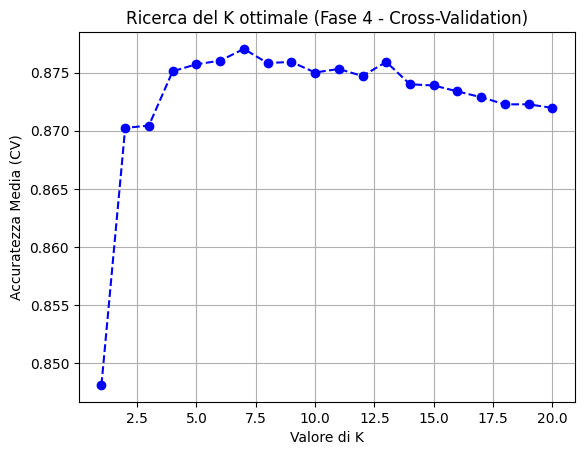

Il valore ottimale di K stimato tramite Cross-Validation è: 7


In [ ]:
k_range = range(1, 21)
cv_scores = []

for k in k_range:
    knn_temp = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn_temp, X_train_scaled, y_train, cv=5, scoring='accuracy')
    cv_scores.append(np.mean(scores))

plt.plot(k_range, cv_scores, marker='o', color='blue', linestyle='dashed')
plt.xlabel('Valore di K')
plt.ylabel('Accuratezza Media (CV)')
plt.title('Ricerca del K ottimale (Fase 4 - Cross-Validation)')
plt.grid(True)
plt.show()

best_k = k_range[np.argmax(cv_scores)]
print(f"Il valore ottimale di K stimato tramite Cross-Validation è: {best_k}")

Il k con maggiore accuratezza sembra essere il valore 7. Ora addestro il modello con questo k (verranno quindi presi i 7 vicini più vicini).

In [ ]:
%%time
knn_definitivo = KNeighborsClassifier(n_neighbors=best_k)
knn_definitivo.fit(X_train_scaled, y_train)

CPU times: user 6.98 ms, sys: 0 ns, total: 6.98 ms
Wall time: 11.1 ms


KNeighborsClassifier(n_neighbors=7)

Tempo di esecuzione: meno di un secondo.

##Modello SVM

In [ ]:
%%time
model_svm= SVC(kernel= "linear", C=1, random_state=0)
model_svm.fit(X_train_scaled, y_train)

CPU times: user 15.2 s, sys: 85 ms, total: 15.3 s
Wall time: 15.9 s


SVC(C=1, kernel='linear', random_state=0)

Tempo di esecuzione: circa 15 secondi

#Fase 5: Valutazione e interpretazione dei risultati

##Valutazione regressione logistica

In [ ]:
y_prob = lr_model.predict_proba(X_test_scaled)[:, 1]

Scegliamo la soglia con l'accuratezza migliore, facendo il confronto tra soglia 0.5 e soglia 0.7

In [ ]:
y_pred_05 = (y_prob >= 0.5).astype(int)
print(f"Accuracy: {accuracy_score(y_test, y_pred_05):.4f}")

Accuracy: 0.8783


Stampiamo il classification report del modello con soglia 0.5

In [ ]:
print("Classification Report - Soglia 0.5:")
print(classification_report(y_test, y_pred_05))

Classification Report - Soglia 0.5:
              precision    recall  f1-score   support

           0       0.89      0.98      0.93      2084
           1       0.72      0.35      0.47       382

    accuracy                           0.88      2466
   macro avg       0.81      0.66      0.70      2466
weighted avg       0.86      0.88      0.86      2466



In [ ]:
y_pred_07 = (y_prob >= 0.7).astype(int)
print(f"Accuracy: {accuracy_score(y_test, y_pred_07):.4f}")

Accuracy: 0.8735


Stampiamo il classification report del modello con soglia 0.7

In [ ]:
print("Classification Report - Soglia 0.7:")
print(classification_report(y_test, y_pred_07))

Classification Report - Soglia 0.7:
              precision    recall  f1-score   support

           0       0.88      0.99      0.93      2084
           1       0.81      0.24      0.37       382

    accuracy                           0.87      2466
   macro avg       0.84      0.62      0.65      2466
weighted avg       0.87      0.87      0.84      2466



Nonostante la soglia 0.7 abbia trovato meno falsi positivi e più falsi negativi, scegliamo la soglia 0.5.

Misuriamo la matrice di confusione

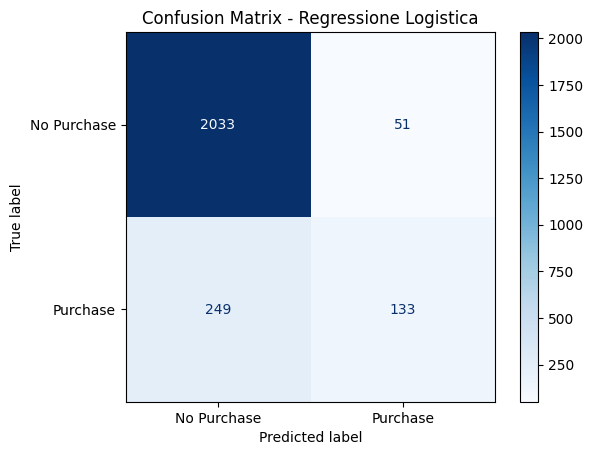

In [ ]:
cm_rl = confusion_matrix(y_test, y_pred_05)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rl, display_labels=['No Purchase', 'Purchase'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - Regressione Logistica')
plt.show()

Analizzando i dati emerge che:


*   **Classe "Nessun acquisto"**: il modello ha individuato 2033 veri negativi e 51 falsi negativi
*   **Classe "Acquisto"**: il modello ha individuato 133 veri positivi e 249 falsi positivi



##Valutazione modello Random Forest

In [ ]:
variabili_indipendenti = pd.get_dummies(shopping.drop('Revenue',
axis=1), drop_first=True)
variabile_target = shopping['Revenue'].astype(int)

Previsioni e report di classificazione (il modello fa le sue previsioni sul dataset)

In [ ]:
pred_rf = modello_rf.predict(X_test)
print(pred_rf)

[0 0 1 ... 0 0 0]


In [ ]:
y_test

,Revenue
4722,0
6835,0
5524,1
663,0
136,0
...,...
4648,0
1804,0
4278,0
6244,0


Calcoliamo l'accuratezza e stampiamo il classification report

In [ ]:
acc_rf = accuracy_score(y_test, pred_rf)
print(f"Accuratezza Globale: {acc_rf:.3f}\n")

print("Report di Classificazione:")
print(classification_report(y_test, pred_rf, target_names=["Nessun Acquisto", "Acquisto"]))

Accuratezza Globale: 0.889

Report di Classificazione:
                 precision    recall  f1-score   support

Nessun Acquisto       0.91      0.96      0.94      2084
       Acquisto       0.70      0.51      0.59       382

       accuracy                           0.89      2466
      macro avg       0.80      0.73      0.76      2466
   weighted avg       0.88      0.89      0.88      2466



Il modello Random Forest ha ottenuto un'accuratezza globale dell'88,9%, dimostrandosi una soluzione affidabile per l'analisi delle sessioni e-commerce. L'analisi del *classification report* evidenzia una capacità eccellente nell'identificare le sessioni che non portano a una transazione (Precision 91%, Recall 96%), confermando la robustezza del modello nel filtrare il traffico non convertibile.

Per quanto riguarda la classe minoritaria ("Acquisto"), il modello mostra una precisione del 70%, indicando una buona affidabilità nelle predizioni positive, a fronte di una recall del 51%. Tale valore, influenzato dallo sbilanciamento intrinseco del dataset, suggerisce che il modello intercetta correttamente circa la metà degli acquirenti reali

Analisi degli errori con la matrice di confusione

[[1999   85]
 [ 188  194]]


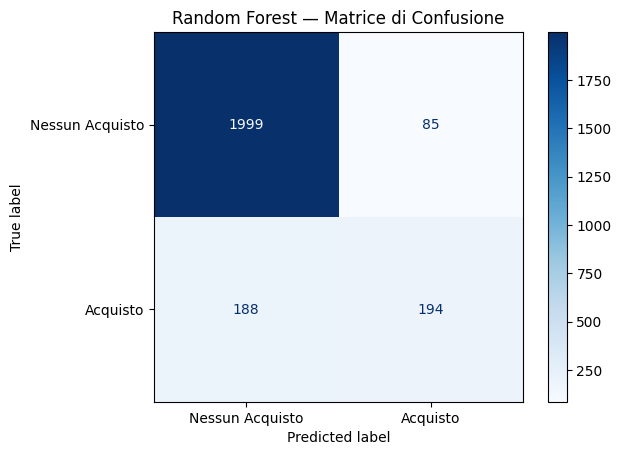

In [ ]:
cm_rf = confusion_matrix(y_test, pred_rf, labels=[0,1])
print(cm_rf)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=["Nessun Acquisto", "Acquisto"])

disp.plot(cmap='Blues')
plt.title("Random Forest — Matrice di Confusione")
plt.show()

Analizzando i dati emerge che:


*   **Classe "Nessun acquisto"**: il modello ha individuato 1999 veri negativi e 85 falsi negativi
*   **Classe "Acquisto"**: il modello ha individuato 194 veri positivi e 188 falsi positivi


Estrazione dell'importanza delle variabili

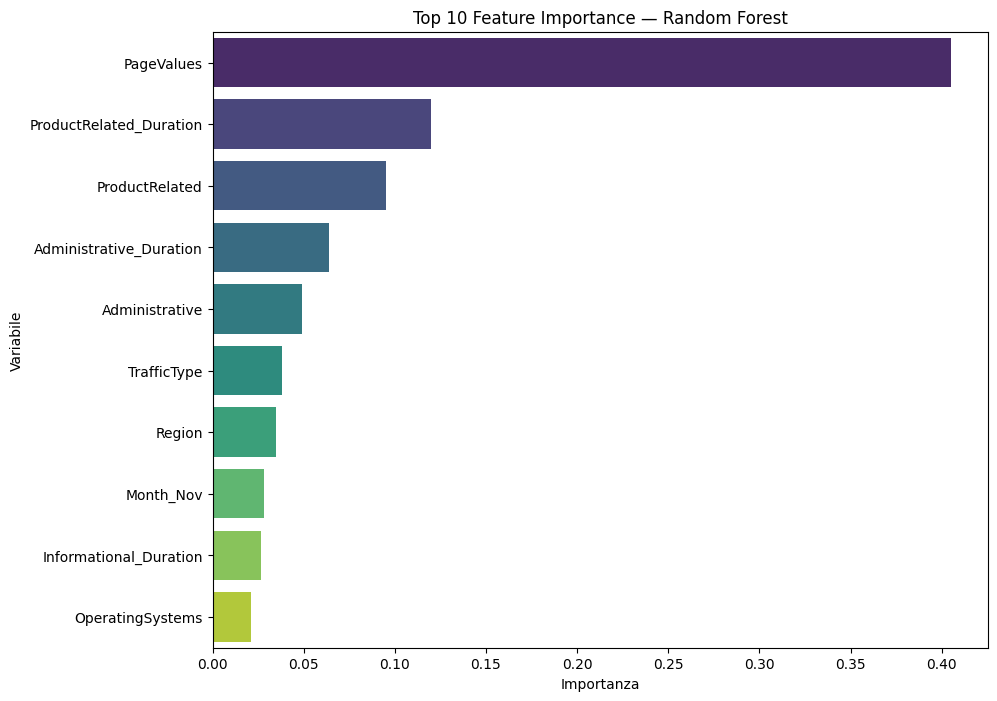

In [ ]:
importanza_variabili = pd.DataFrame({
    "feature": variabili_indipendenti.columns,
    "importanza": modello_rf.feature_importances_
}).sort_values("importanza", ascending=False)


# Grafico delle top 10
plt.figure(figsize=(10, 8))
sns.barplot(
    data=importanza_variabili.head(10),
    x="importanza",
    y="feature",
    hue="feature",
    palette="viridis",
    legend=False
)
plt.title("Top 10 Feature Importance — Random Forest")
plt.xlabel("Importanza")
plt.ylabel("Variabile")
plt.show()

L'analisi dell'importanza delle feature nel modello Random Forest evidenzia quali comportamenti degli utenti sono maggiormente predittivi rispetto all'acquisto finale.
La variabile PageValues emerge nettamente come la più rilevante, confermando che il valore economico attribuito alle pagine visitate prima della transazione è il principale indicatore di conversione.
Seguono, con un peso significativo, le variabili legate all'interazione con i contenuti, come ProductRelated_Duration e ExitRates.
Questa analisi conferma che il modello non si basa su correlazioni casuali, ma su indicatori comportamentali solidi, rendendolo uno strumento affidabile per indirizzare le strategie di ottimizzazione del tasso di conversione.


##Valutazione modello k-NN

Ora possiamo usare il modello per ottenere una previsione sull'intenzione di acquisto degli utenti.

In [ ]:
y_pred_knn = knn_definitivo.predict(X_test_scaled)
print(y_pred_knn)

[0 0 1 ... 0 0 0]


Confrontiamo questi valori con quelli contenuti in *y_test*.

In [ ]:
y_test

,Revenue
4722,0
6835,0
5524,1
663,0
136,0
...,...
4648,0
1804,0
4278,0
6244,0


Un confronto sui primi e sugli ultimi dati evidenzia che le previsioni del modello coincidono con i valori reali: sia i primi tre sia gli ultimi tre valori vengono classificati correttamente.

Misuro l'accuratezza del modello sull'intero dataset

In [ ]:
accuracy_knn = accuracy_score(y_test, y_pred_knn)
print(f"Accuracy del modello: {accuracy_knn:.4f} ({accuracy_knn * 100:.2f}%)")


Accuracy del modello: 0.8715 (87.15%)


L'accuratezza del modello è del 87.15%.

Misuro la matrice di confusione

[[2024   60]
 [ 257  125]]


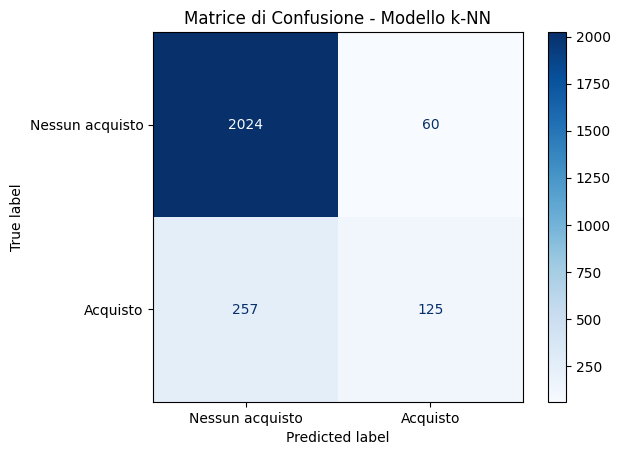

In [ ]:
cm_knn = confusion_matrix(y_test, y_pred_knn, labels=[0,1])
print(cm_knn)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=["Nessun acquisto", "Acquisto"])
disp.plot(cmap=plt.cm.Blues, values_format='d')

plt.title("Matrice di Confusione - Modello k-NN")
plt.grid(False)
plt.show()

Analizzando i dati emerge che:


*   **Classe "Nessun acquisto"**: il modello ha individuato 2024 veri negativi e 60 falsi negativi;
*   **Classe "Acquisto"**: il modello ha individuato 125 veri positivi e 257 falsi positivi



Stampo il classification report

In [ ]:
report_knn = classification_report(y_test, y_pred_knn, target_names=["No Revenue (0)", "Revenue (1)"])
print("Classification report:")
print(report_knn)


Classification report:
                precision    recall  f1-score   support

No Revenue (0)       0.89      0.97      0.93      2084
   Revenue (1)       0.68      0.33      0.44       382

      accuracy                           0.87      2466
     macro avg       0.78      0.65      0.68      2466
  weighted avg       0.85      0.87      0.85      2466



Dal report emerge che:

- **Classe "Nessun acquisto":** la precision è del 89% e il recall del 97%: il modello li individua quasi tutti e con pochissimi falsi positivi;
- **Classe  "Acquisto":** la precision è del 68% e il recall del 33%: questa classe non viene riconosciuta in modo molto accurato.

##Valutazione modello SVM

A questo punto possiamo usare il modello SVM che ha appreso i dati del training dataset per classificare i dati nel dataset con il sottogruppo di variabili

In [ ]:
pred_svm= model_svm.predict(X_test_scaled)
pred_svm

array([0, 0, 1, ..., 0, 0, 0])

Possiamo confrontare questi valori con quelli contenuti nella variabile *y_test*

In [ ]:
y_test

,Revenue
4722,0
6835,0
5524,1
663,0
136,0
...,...
4648,0
1804,0
4278,0
6244,0


Dai primi e dagli ultimi tre dati constatiamo che le etichette sono state calcolate correttamente dal modello SVM.

Calcoliamo l'accuratezza

In [ ]:
accuracy_score (y_test, pred_svm)

0.8815896188158961

L'accuratezza è circa dell'88%.

Stampiamo la matrice di confusione

[[2031   53]
 [ 239  143]]


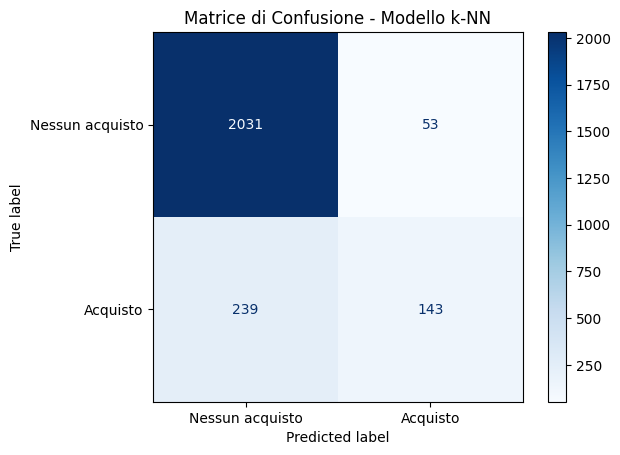

In [ ]:
cm_svm = confusion_matrix(y_test, pred_svm, labels=[0,1])
print(cm_svm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_svm, display_labels=["Nessun acquisto", "Acquisto"])
disp.plot(cmap=plt.cm.Blues, values_format='d')

plt.title("Matrice di Confusione - Modello k-NN")
plt.grid(False)
plt.show()

Analizzando i dati emerge che:


*   **Classe "Nessun acquisto"**: il modello ha individuato 2031 veri negativi e 53 falsi negativi;
*   **Classe "Acquisto"**: il modello ha individuato 143 veri positivi e 239 falsi positivi



Stampiamo un report con le principali metriche che misurano i risultati della classificazione

In [ ]:
cr= classification_report(y_test, pred_svm)
print(cr)

              precision    recall  f1-score   support

           0       0.89      0.97      0.93      2084
           1       0.73      0.37      0.49       382

    accuracy                           0.88      2466
   macro avg       0.81      0.67      0.71      2466
weighted avg       0.87      0.88      0.87      2466



Dal report emerge che:

- **Classe "Nessun acquisto":** la precision è del 89% e il recall del 97%: il modello li individua quasi tutti e con pochissimi falsi positivi;
- **Classe  "Acquisto":** la precision è del 73% e il recall del 37%: questa classe non viene riconosciuta in modo molto accurato.

##Confronto tra modelli

In [ ]:
confronto_modelli = pd.DataFrame({
    "Modello": [
        "Regressione Logistica",
        "Random Forest",
        "k-NN",
        "SVM"
    ],
    "Accuracy": [0.8783, 0.8999, 0.8715, 0.8815],
    "Tempo addestramento (s)": [0.04, 3, 0.06, 15]
})

confronto_modelli


,Modello,Accuracy,Tempo addestramento (s)
0,Regressione Logistica,0.8783,0.04
1,Random Forest,0.8999,3.00
2,k-NN,0.8715,0.06
3,SVM,0.8815,15.00


Dal confronto emerge che tutti i modelli raggiungono prestazioni elevate, con un'accuratezza superiore all'87%. La Random Forest risulta il modello migliore, ottenendo l'accuracy più alta (89,99%) e mostrando un buon equilibrio tra precisione e capacità di individuare gli utenti che effettuano un acquisto. La SVM e la Regressione Logistica ottengono risultati molto simili, con prestazioni leggermente inferiori, mentre il k-NN è il modello meno performante. Poiché il dataset presenta un forte sbilanciamento tra le classi, è importante considerare anche il **recall** della classe "Acquisto": sotto questo aspetto la Random Forest conferma la propria superiorità, riconoscendo circa il 51% degli acquirenti reali, contro il 37% della SVM, il 35% della Regressione Logistica e il 33% del k-NN. Considerando sia l'accuratezza sia la capacità di individuare la classe minoritaria, la **Random Forest** rappresenta il modello più adatto per questo problema di classificazione.

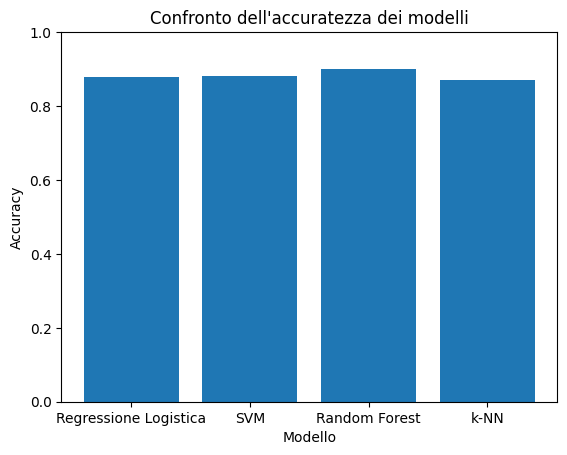

In [ ]:
confronto_modelli = pd.DataFrame({
    "Modello": [
        "Regressione Logistica",
        "SVM",
        "Random Forest",
        "k-NN"
    ],
    "Accuracy": [0.8783, 0.8815, 0.8999, 0.8715]
})

plt.bar(confronto_modelli["Modello"],
        confronto_modelli["Accuracy"])

plt.title("Confronto dell'accuratezza dei modelli")
plt.xlabel("Modello")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.show()